In [9]:
import pyvisa
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('TCPIP::169.254.5.2::INSTR', 'TCPIP::169.254.5.2::INSTR', 'TCPIP::169.254.5.2::INSTR', 'TCPIP::169.254.5.2::INSTR')


In [10]:
# local_addr = "169.254.5.2"
# socket = f"TCPIP::{local_addr}::5025::SOCKET"
# inst: pyvisa.resources.Resource
# try:
#     inst = rm.open_resource(socket)
#     print(inst.query("*IDN?"))
# except pyvisa.VisaIOError as e:
#     print(f"Failed to connect to the instrument: {e}")

In [11]:
socket2 = "TCPIP::169.254.5.2::INSTR"
try:
    inst = rm.open_resource(socket2)
    print(inst.query("*IDN?"))
except pyvisa.VisaIOError as e:
    print(f"Failed to connect to the instrument: {e}")

Agilent Technologies,B2902A,MY51140533,2.0.1225.1717



In [12]:
# Reset the instrument
inst.write("*RST")

6

In [13]:
def beep_up(inst):
    inst.write(":SYST:BEEP:STAT ON")
    inst.write(":SYST:BEEP 800, 0.1")
    inst.write(":SYST:BEEP 1000, 0.1")
    inst.write(":SYST:BEEP 1200, 0.1")
    inst.write(":SYST:BEEP 1600, 0.4")
# beep_up(inst)

def beep_dn(inst):
    inst.write(":SYST:BEEP:STAT ON")
    inst.write(":SYST:BEEP 1600, 0.1")
    inst.write(":SYST:BEEP 1200, 0.1")
    inst.write(":SYST:BEEP 1000, 0.1")
    inst.write(":SYST:BEEP 800, 0.4")
# beep_dn(inst)

In [14]:
import datetime
now = datetime.datetime.now()
date = now.strftime("%Y,%m,%d")
time = now.strftime("%H,%M,%S")
inst.write(f":SYST:DATE {date}")
inst.write(f":SYST:TIME {time}")

21

In [ ]:
# Set the output voltage
# Turn on the source
inst.write(":OUTP ON")
# Set the  mode
inst.write(":SOUR:FUNC:MODE VOLT")
# Set the current reading mode
inst.write(":sens:func ""curr""")
# Autorange the current
inst.write(":sens:curr:rang:auto on")
# # Set number of power line cycles (NPLC) for current measurement 
# inst.write(":sens:curr:nplc 0.1")
# Set the aperature time for current measurement
inst.write(":sens:curr:aper 0.01")
# Set the sense limit
inst.write(":sens:curr:prot 0.1")


21

In [ ]:
# Turn off the source
inst.write(":OUTP OFF")

In [ ]:
import time
t0 = time.time()
# Set the voltage output
inst.write(":SOUR:VOLT 0.8")
# Set the voltage output
beep_up(inst)
timeseries = []

while time.time() - t0 < 5.0:
    # Wait for 5 seconds
    time.sleep(0.001)
    

s = inst.query(":meas:curr? (@1)")
print(f"Current reading: {s}")

# Set the voltage output to 0V
inst.write(":SOUR:VOLT 0")
beep_dn(inst)


Current reading: +7.170600E-08



In [ ]:
# Collect the current reading while running the source


In [41]:
inst.close()

In [30]:
I = 0.8 / 100
I

0.008

Text(0.5, 1.0, 'Current Measurement Over Time (Datapoints = 1000)')

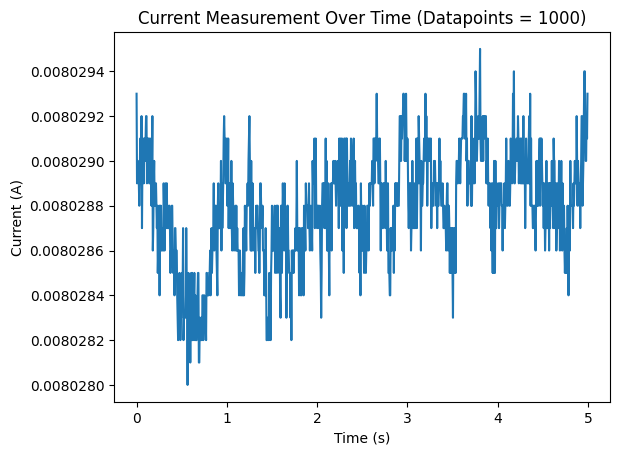

In [33]:
import time
total_time = 5.0
deltat = 0.005
N = int(total_time / deltat)  # Number of points to collect

inst.write("*RST")  # Reset the instrument
time.sleep(0.5)  # Wait for the instrument to reset

trig_volt = 0.8

# Set voltage mode
inst.write(":sour:func:mode volt")
inst.write(f":sour:volt:trig {trig_volt:0.2e}")  # Set the trigger voltage to 0.8V
# Set the current protection limit at 0.1 A
inst.write(":sens:curr:prot 0.1")
# Setup current acquisition
inst.write(":sens:func ""curr""")
inst.write(":sens:curr:rang:auto on")  # Auto range for current
inst.write(":sens:curr:aper 1e-3")  # Set aperture time for current measurement

# Setup the multiple acquisition
inst.write(":trig:acq:del 2.0e-3") # Change the trigger delay to 2ms
inst.write(":trig:sour tim") # Set the trigger source to time
inst.write(f":trig:tim {deltat:0.2e}") # Set the trigger time to 4ms (use scientific 4e-3)
inst.write(f":trig:coun {N}") # Set the trigger count to 6

# Make sure the output is on
inst.write(":outp on")

time.sleep(0.5) # Wait for the instrument to settle

# Start the measurement
t0 = time.time()
inst.write(":init (@1)")

time.sleep(0.5)

# Set the voltage output
beep_up(inst)
trig_volt = 0.2
inst.write(f":sour:volt:trig {trig_volt:0.2e}")  # Set the trigger voltage to 0.2V
inst.write(f":sour:volt {trig_volt}")  # Set the voltage output to 0.8V
# Set the voltage output    

time.sleep(3.0)
# s = inst.query(":meas:curr? (@1)")
# print(f"Current reading: {s}")

# Set the voltage output to 0V
trig_volt = 0.0
inst.write(f":SOUR:VOLT {trig_volt:0.2e}")
beep_dn(inst)

time.sleep(2) # wait another 7 seconds for the measurement to complete

arr = inst.query(":fetc:arr:curr? (@1)")

import matplotlib.pyplot as plt
import numpy as np
data = np.array(arr.split(","),dtype=float)
t = np.arange(len(data)) * deltat  # Create a time array based on the number of points and the time step
plt.plot(t, data)
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.title(f"Current Measurement Over Time (Datapoints = {len(data)})")


Text(0.5, 1.0, 'Current Measurement Over Time (Datapoints = 436)')

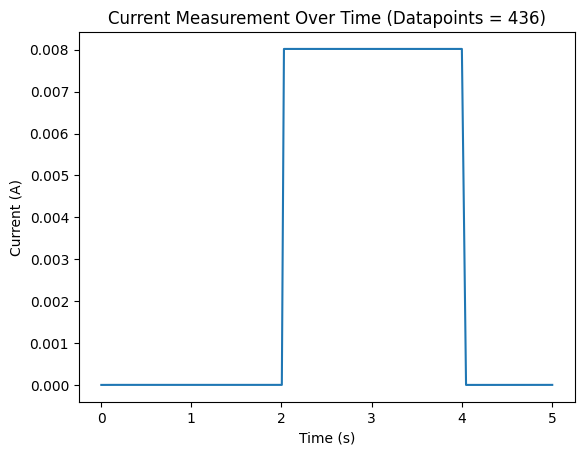

In [43]:
import time
total_time = 5.0
deltat = 0.005
N = int(total_time / deltat)  # Number of points to collect

inst.write("*RST")  # Reset the instrument
time.sleep(0.5)  # Wait for the instrument to reset

trig_volt = 0.8

# Set voltage mode
inst.write(":sour:func:mode volt")

# Set the current protection limit at 0.1 A
inst.write(":sens:curr:prot 0.1")
# Setup current acquisition
inst.write(":sens:func ""curr""")
inst.write(":sens:curr:rang:auto on")  # Auto range for current
inst.write(":sens:curr:aper 1e-3")  # Set aperture time for current measurement

# Make sure the output is on
inst.write(":outp on")

time.sleep(0.5) # Wait for the instrument to settle

# Start the measurement
t0 = time.time()
datapoints = []

on_time = 2.0
offtime = 4.0

t = 0
while t < on_time:
    t = time.time() - t0
    current = float(inst.query(":meas:curr? (@1)"))
    datapoints.append((t, current))
    
beep_up(inst)
inst.write(f":sour:volt {trig_volt}")  # Set the voltage output to 0.8V

while t < offtime:
    t = time.time() - t0
    current = float(inst.query(":meas:curr? (@1)"))
    datapoints.append((t, current))

inst.write(f":sour:volt 0")  # Set the voltage output to 0.8V
beep_dn(inst)

while t < offtime+1:
    t = time.time() - t0
    current = float(inst.query(":meas:curr? (@1)"))
    datapoints.append((t, current))

data = np.array(datapoints, dtype=float)
plt.plot(data[:, 0], data[:, 1])
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.title(f"Current Measurement Over Time (Datapoints = {len(data)})")


In [ ]:
# Start, Stop

# Do acquisition for X seconds.